In [20]:
import sys
import os

# add src folder to path
sys.path.append(os.path.abspath("../src")) 

from imports import * 

In [ ]:
''' 
This notebook performs data collection and analysis on the forex data. 
    
    1. Collect and preprocess financial time series data:
        Retrieve Forex price data (EURUSD, USDCAD) using yfinance (done)
        Compute daily returns and log returns  (done)
        Compute squared returns -> volatility approx. (done)

    2. Perform Exploratory Data analysis
        A. Visual Analysis
            Plot of Prices (done)
            Plot of Returns (done)
            Plot of Volatility (done)
            Histogram of Returns w theoretical normal (done)
            QQplot of Returns (done) 
            ACF and PACF plots
                - returns (done)
                - volatility (done)

        B. Quantitative Analysis
            Summary statistics of returns (done)
            Rolling statistics
            Stationarity: Augmented Dickey-Fuller test and KPSS test
                - prices -> should be non stationary (done)
                - returns -> should be stationary (done)
            Returns distribution - Normality: Jarque-Bera test (done)
            Autocorrelation Significance: Ljung-Box test
                - returns (done)
                - volatility
            Heteroskedasticity: ARCH LM test
'''

' \nThis notebook performs data collection and analysis on the forex data. \n\n    1. Collect and preprocess financial time series data:\n        Retrieve Forex price data (EURUSD, USDCAD) using yfinance (done)\n        Compute daily returns and log returns  (done)\n        Compte suqared returns\n\n    2. Perform Exploratory Data analysis\n        Visual Analysis\n            Plot of Prices (done)\n            Plot of Returns (done)\n            Histogram w theoretical normal (done)\n            QQplots (done)\n            ACF and PACF plots\n                - returns (done)\n                - squared returns\n\n        Quantitative Analysis\n            Returns distribution: Jarque-Bera test (done)\n            Autocorrelation Significance: Ljung-Box test\n                - returns (done)\n                - squared returns\n            Heteroskedasticity: ARCH LM test\n'

# Collect and Process Data

In [35]:
# Load FOREX data
# EUR/USD, BTC/USD and USD/CAD
tickers = ["EURUSD=X", 
            # "BTD-USD", # starts in 2021
            "CAD=X"] 
start, end = "2014-01-01", "2024-06-30" 

data = yf.download(tickers, start=start, end=end, progress=False)
prices = data["Close"].copy()
prices.dropna(inplace=True)

prices.set_index(prices.index, inplace=True)
prices.columns = tickers

# save data to csv
prices.to_csv("../data/prices.csv")

# check data
print(prices.info())
prices.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2735 entries, 2014-01-01 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2735 non-null   float64
 1   CAD=X     2735 non-null   float64
dtypes: float64(2)
memory usage: 64.1 KB
None


,EURUSD=X,CAD=X
Date,,
2014-01-01,1.06193,1.374495
2014-01-02,1.06445,1.376671
2014-01-03,1.06691,1.366662
2014-01-06,1.06305,1.359601
2014-01-07,1.06609,1.363196


In [36]:
# Daily returns :
returns = prices.pct_change().dropna()*100

# save returns to csv
returns.to_csv("../data/returns.csv")

# check returns
print(returns.info())
returns.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2734 entries, 2014-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2734 non-null   float64
 1   CAD=X     2734 non-null   float64
dtypes: float64(2)
memory usage: 64.1 KB
None


,EURUSD=X,CAD=X
Date,,
2014-01-02,0.237312,0.158325
2014-01-03,0.231106,-0.727065
2014-01-06,-0.361792,-0.516652
2014-01-07,0.285965,0.264468
2014-01-08,1.051503,-0.114382


In [37]:
# Log returns :
log_returns = np.log(prices / prices.shift(1)).dropna()*100

# save log returns to csv
log_returns.to_csv("../data/log_returns.csv")

# check log returns
print(log_returns.info())
log_returns.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2734 entries, 2014-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  2734 non-null   float64
 1   CAD=X     2734 non-null   float64
dtypes: float64(2)
memory usage: 64.1 KB
None


,EURUSD=X,CAD=X
Date,,
2014-01-02,0.237031,0.158200
2014-01-03,0.230839,-0.729721
2014-01-06,-0.362448,-0.517991
2014-01-07,0.285557,0.264119
2014-01-08,1.046013,-0.114448


In [38]:
# compute squared returns
returns_sq = returns**2
returns_sq

,EURUSD=X,CAD=X
Date,,
2014-01-02,0.056317,0.025067
2014-01-03,0.053410,0.528623
2014-01-06,0.130894,0.266929
2014-01-07,0.081776,0.069943
2014-01-08,1.105658,0.013083
...,...,...
2024-06-24,0.014714,0.030349
2024-06-25,0.100333,0.177007
2024-06-26,0.000549,0.046340


# Exploratory Data Analysis

## Visual Analysis

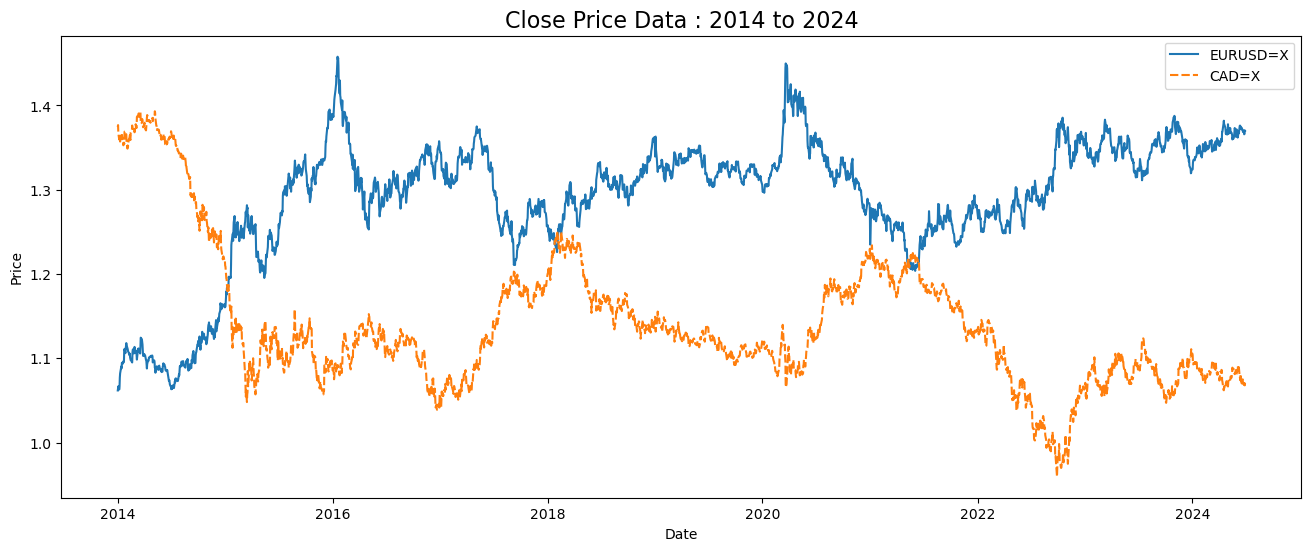

In [93]:
# Plot price data
plt.figure(figsize=(16, 6))

sns.lineplot(data=prices)

title = "Close Price Data"
plt.title(f"{title} : {start[:4]} to {end[:4]}", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

# save plot
plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

plt.show()

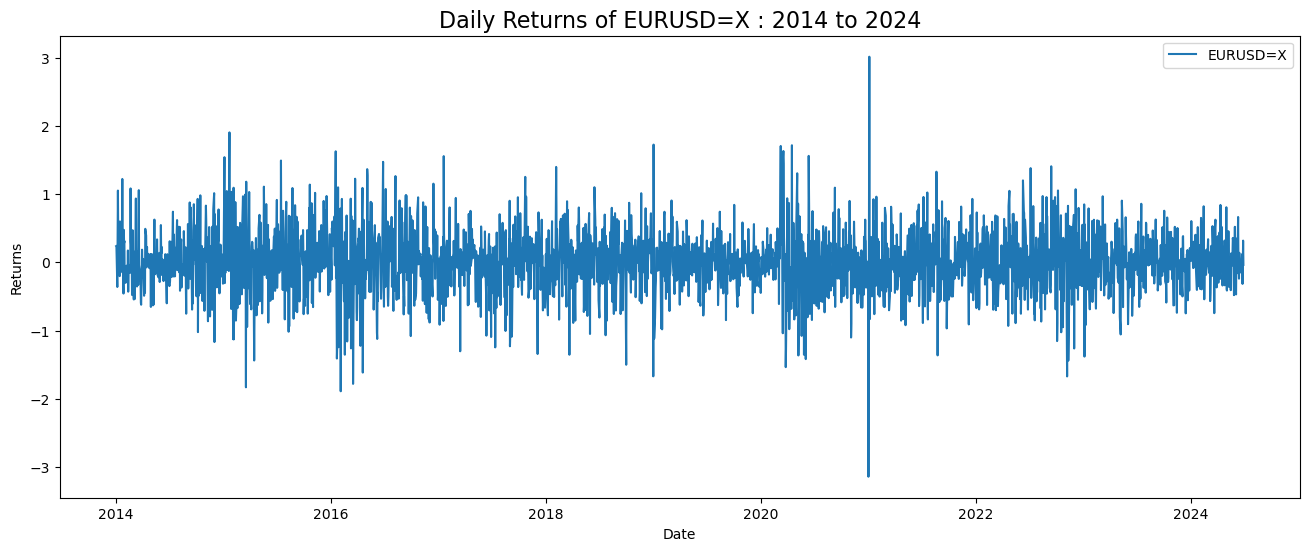

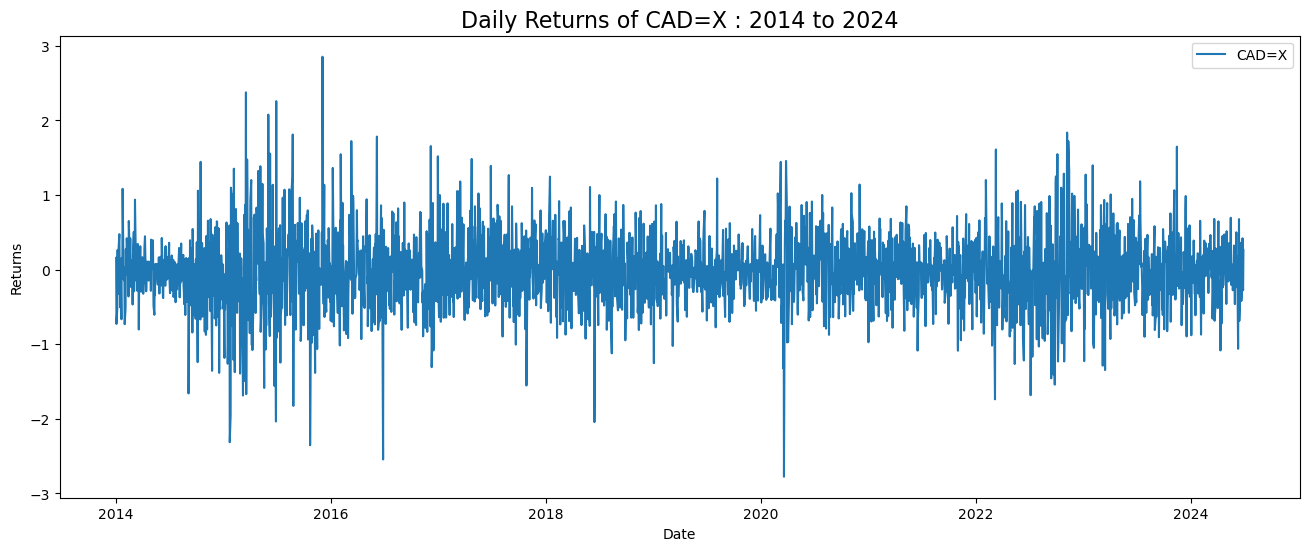

In [ ]:
# Plot returns data
for ticker in tickers:
    plt.figure(figsize=(16, 6))

    sns.lineplot(data=returns[ticker], label=ticker)

    title = f"Daily Returns of {ticker}"
    plt.title(f"{title} : {start[:4]} to {end[:4]}", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    plt.legend()

    # save plot
    # plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

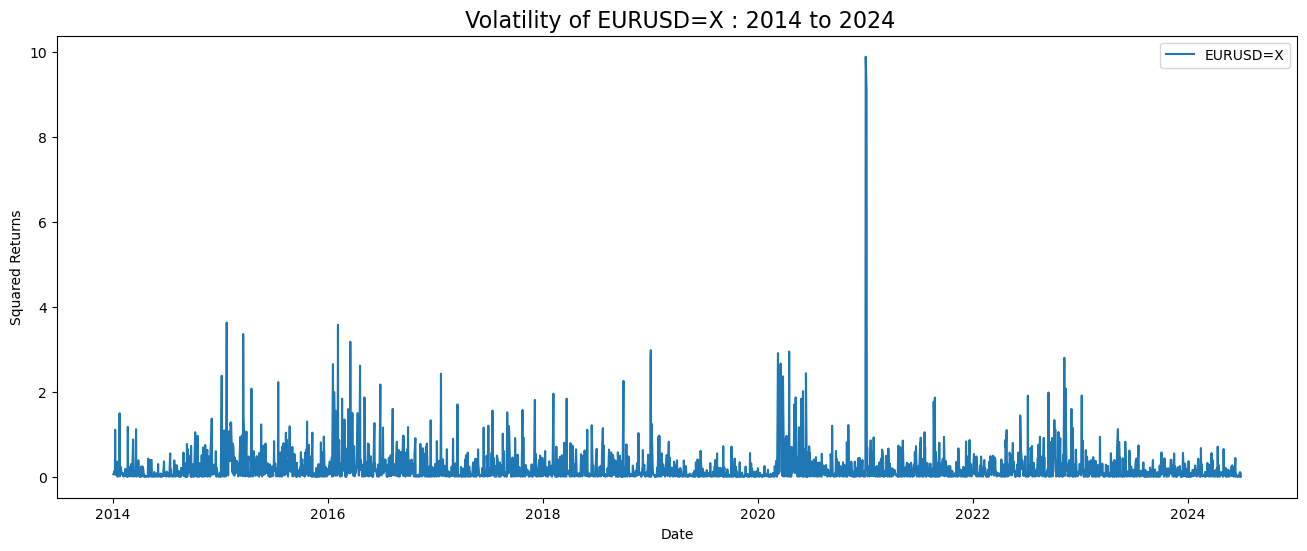

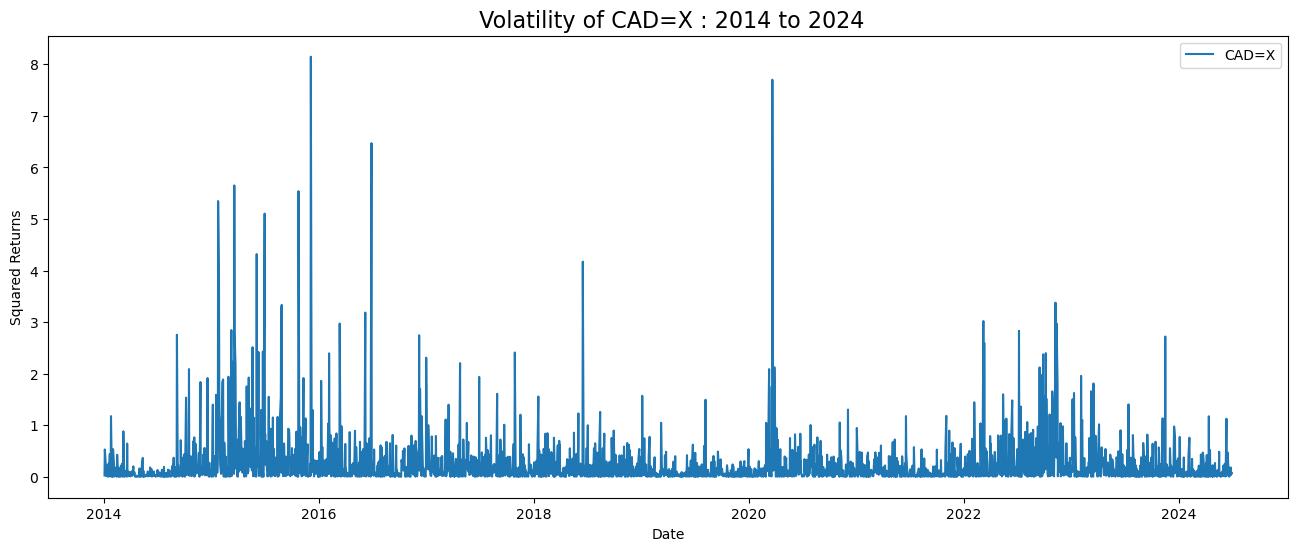

In [ ]:
# Plot volatility data
for ticker in tickers:
    plt.figure(figsize=(16, 6))

    sns.lineplot(data=returns_sq[ticker], label=ticker)

    title = f" Volatility of {ticker}"
    plt.title(f"{title} : {start[:4]} to {end[:4]}", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Squared Returns")
    plt.legend()

    # save plot
    # plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

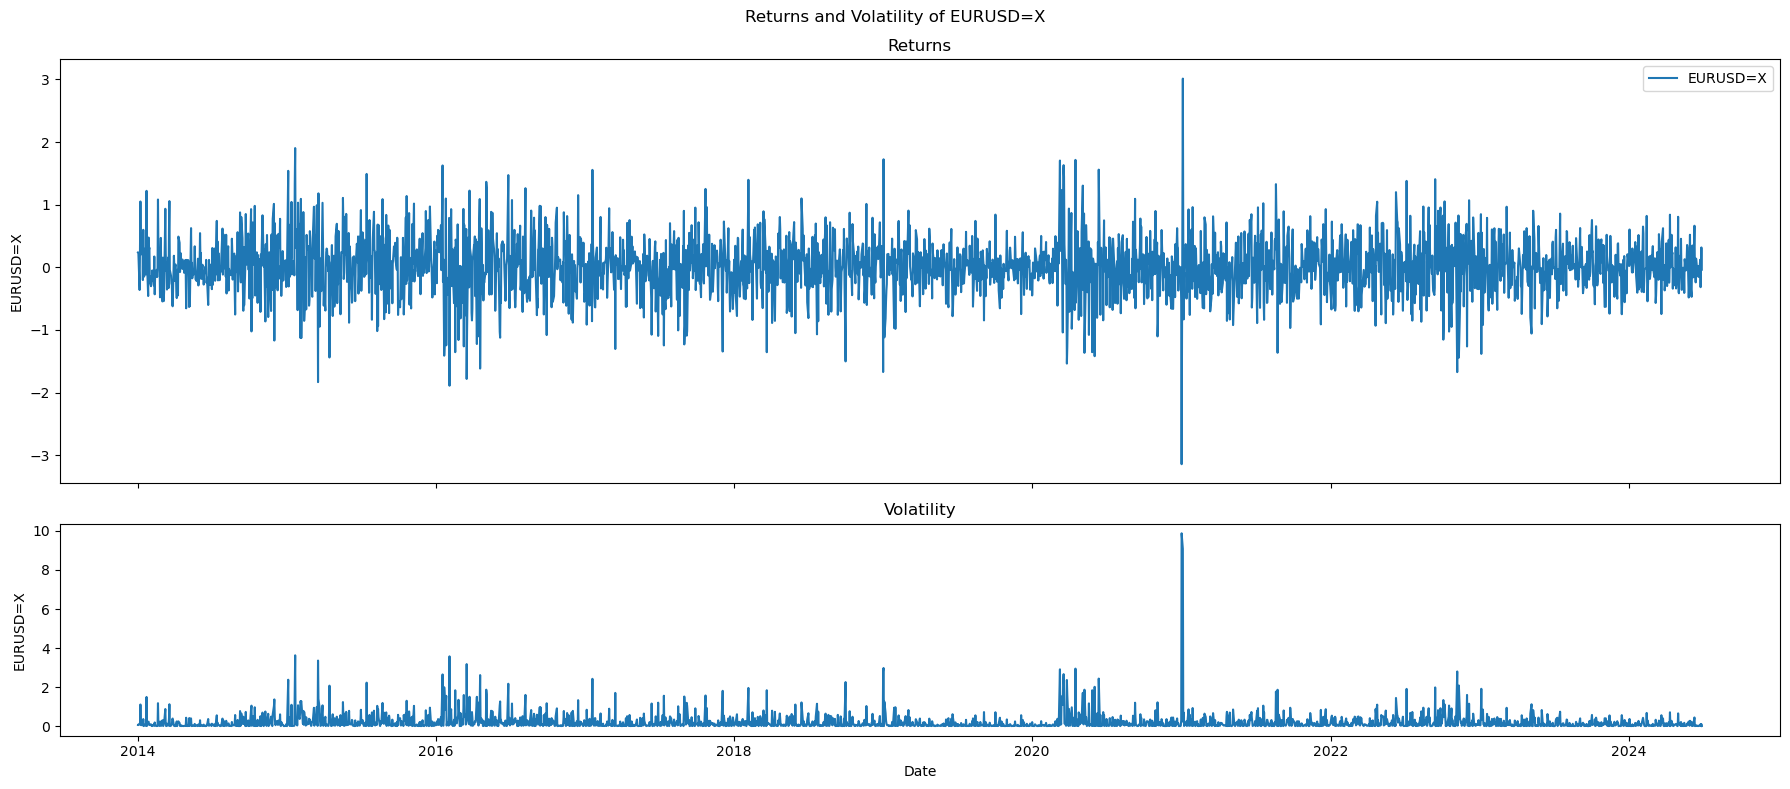

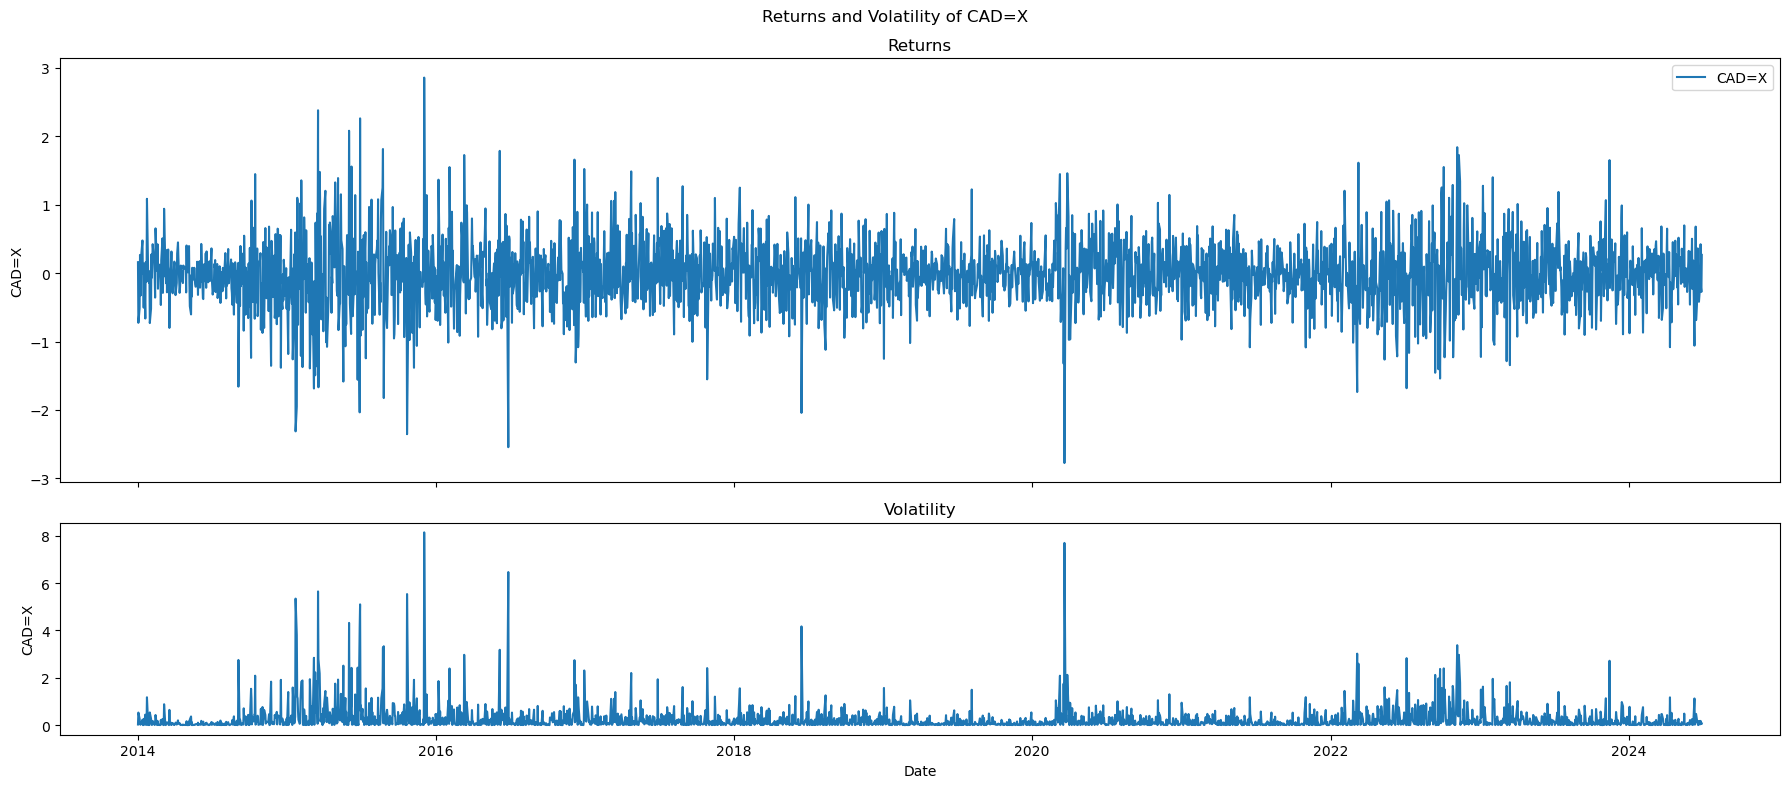

In [92]:
# plot both returns and volatility in one figure
for ticker in tickers:
    fig, axes = plt.subplots(2, figsize=(18,8), sharex=True, gridspec_kw={'height_ratios':[2, 1]})

    title = f'Returns and Volatility of {ticker}'
    plt.suptitle(title)

    sns.lineplot(data=returns[ticker], label=ticker, ax=axes[0])
    axes[0].set_title('Returns') 

    sns.lineplot(data=returns_sq[ticker], ax=axes[1])
    axes[1].set_title('Volatility') 

    # save plot
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")


    plt.tight_layout()
    plt.show()

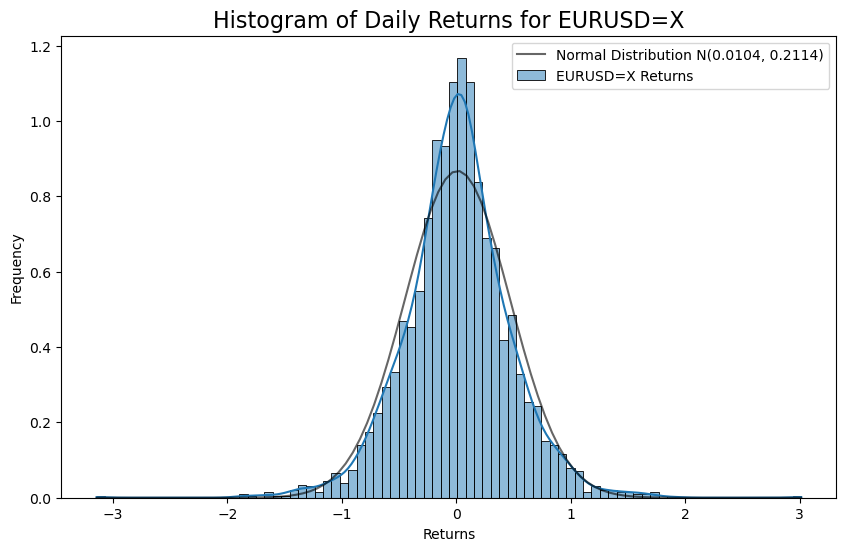

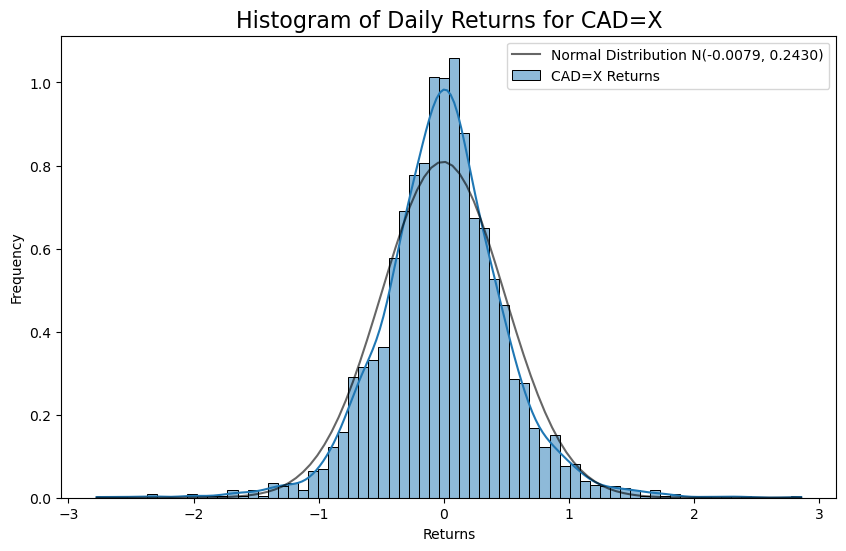

In [94]:
# Plot histogram of returns
for ticker in tickers:
    plt.figure(figsize=(10, 6))

    # Empirical distribution of returns
    sns.histplot(data=returns[ticker], 
        bins='auto', 
        kde=True,
        stat='density', 
        label=f'{ticker} Returns')

    # Theoretical normal distribution curve
    mean = returns[ticker].mean()
    std = returns[ticker].std()
    x = np.linspace(returns[ticker].min(), returns[ticker].max(), 100)
    pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
    plt.plot(x, pdf, 
        alpha=0.6, 
        color='black', 
        label='Normal Distribution N({:.4f}, {:.4f})'.format(mean, std**2))

    title = f"Histogram of Daily Returns for {ticker}"
    plt.title(title, fontsize=16)
    plt.xlabel("Returns")
    plt.ylabel("Frequency")
    plt.legend()

    # save plot
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

<Figure size 1000x600 with 0 Axes>

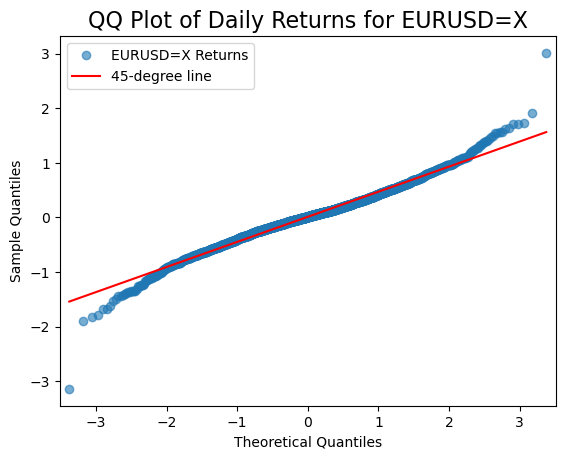

<Figure size 1000x600 with 0 Axes>

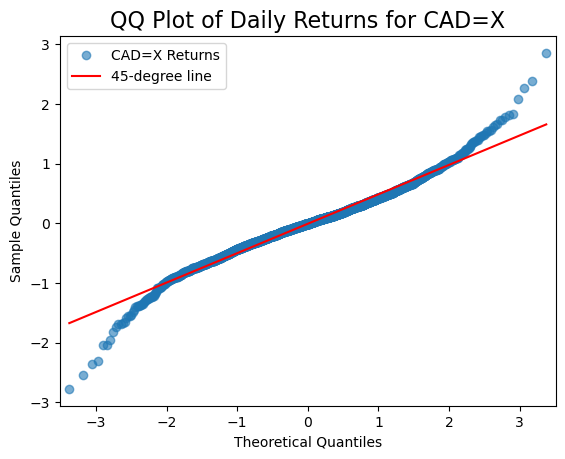

In [95]:
# QQ plots for ticker in tickers
for ticker in tickers:
    plt.figure(figsize=(10, 6))

    # QQ plot
    sm.qqplot(returns[ticker], line='s', alpha=0.6, color='blue')

    title = f"QQ Plot of Daily Returns for {ticker}"
    plt.title(title, fontsize=16)
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.legend([f'{ticker} Returns', '45-degree line'])

    # save plot
    plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

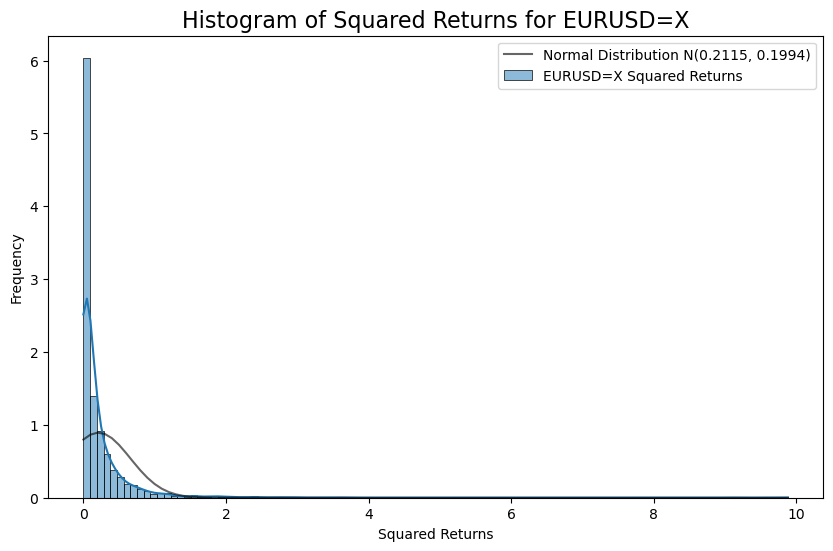

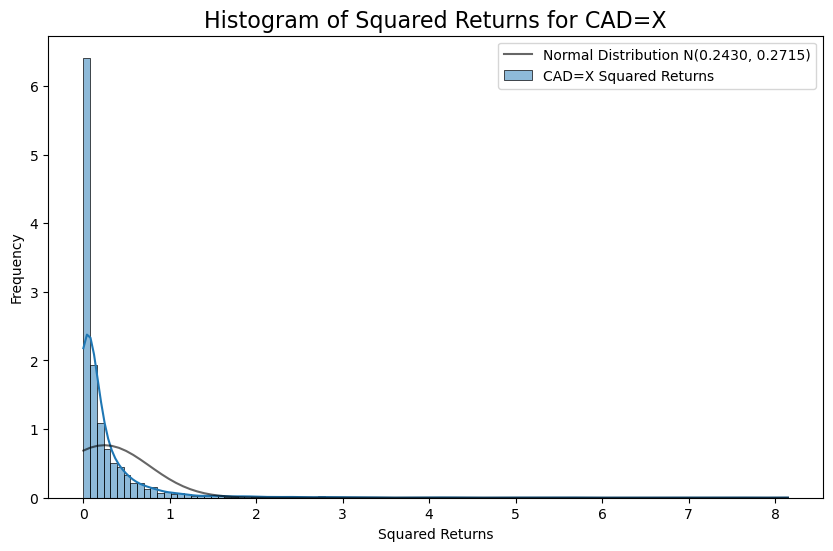

In [43]:
# Plot histogram of squared returns
for ticker in tickers:
    plt.figure(figsize=(10, 6))

    # Empirical distribution of squared returns
    sns.histplot(data=returns_sq[ticker], 
        bins='auto', 
        kde=True,
        stat='density', 
        label=f'{ticker} Squared Returns')

    # Theoretical normal distribution curve
    mean = returns_sq[ticker].mean()
    std = returns_sq[ticker].std()
    x = np.linspace(returns_sq[ticker].min(), returns_sq[ticker].max(), 100)
    pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
    plt.plot(x, pdf, 
        alpha=0.6, 
        color='black', 
        label='Normal Distribution N({:.4f}, {:.4f})'.format(mean, std**2))

    title = f"Histogram of Squared Returns for {ticker}"
    plt.title(title, fontsize=16)
    plt.xlabel("Squared Returns")
    plt.ylabel("Frequency")
    plt.legend()

    # save plot
    # plt.savefig(f"../results/figures/{title}.png", dpi=300, bbox_inches="tight")

    plt.show()

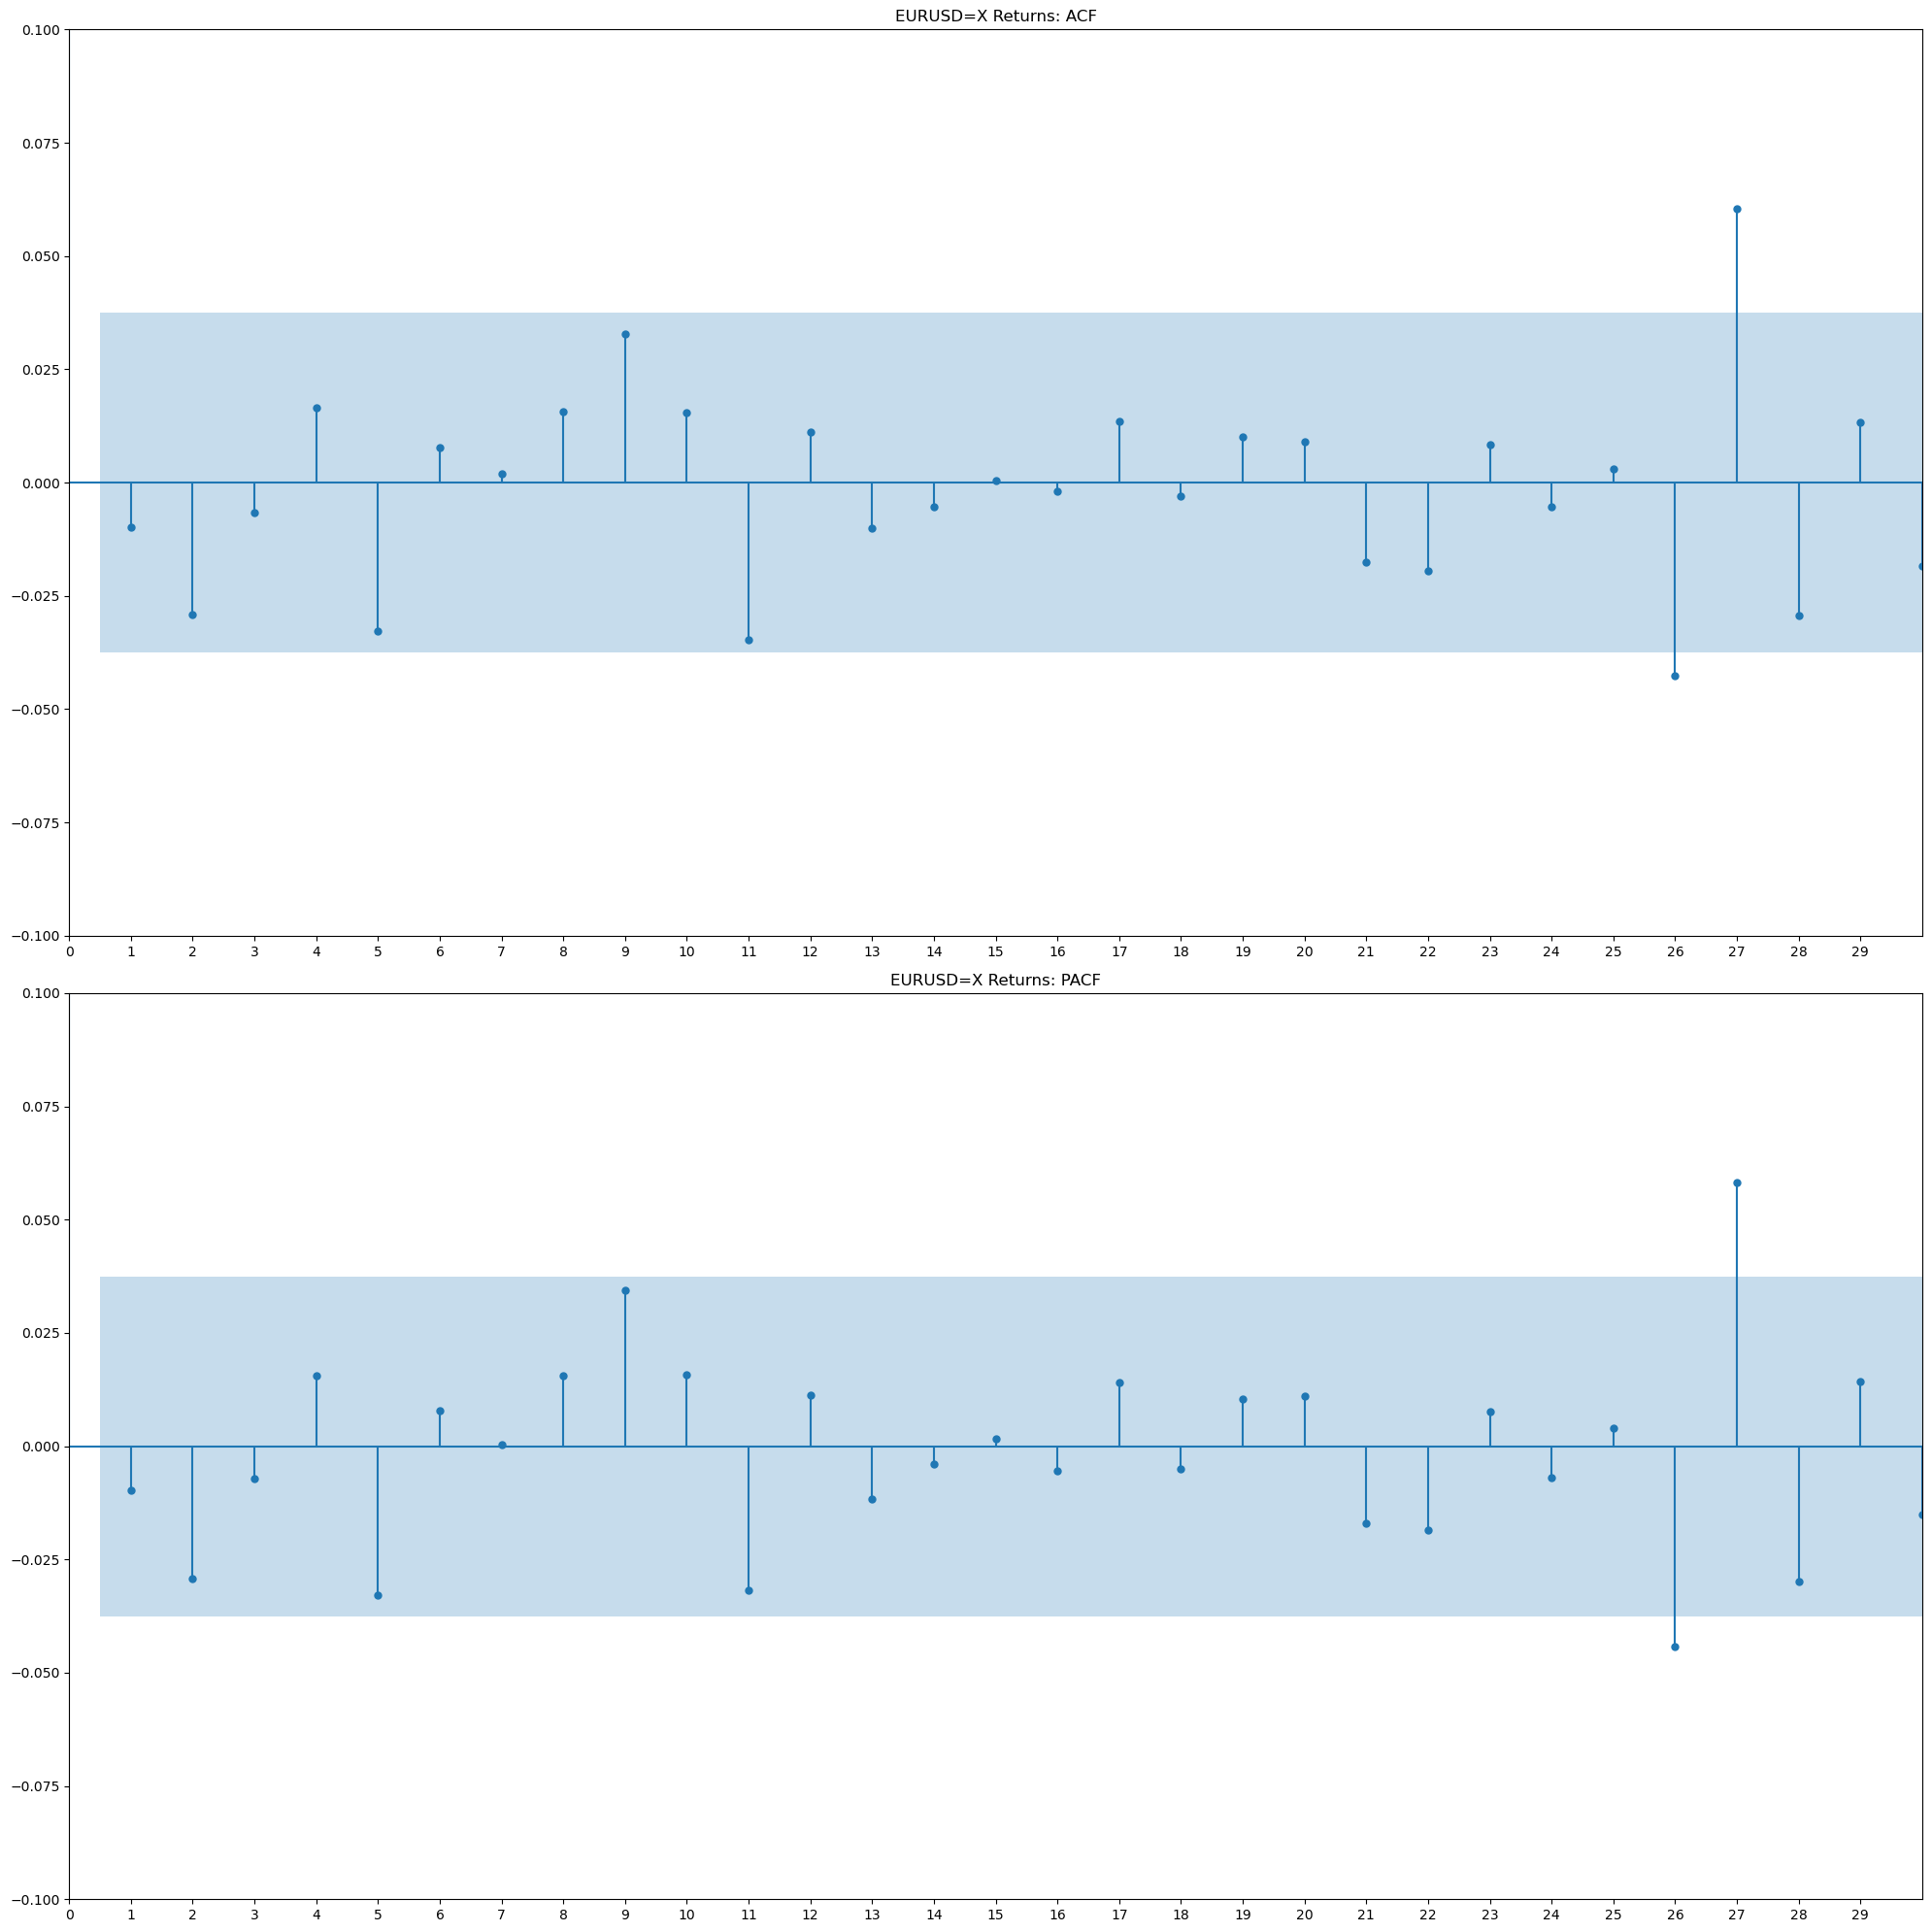

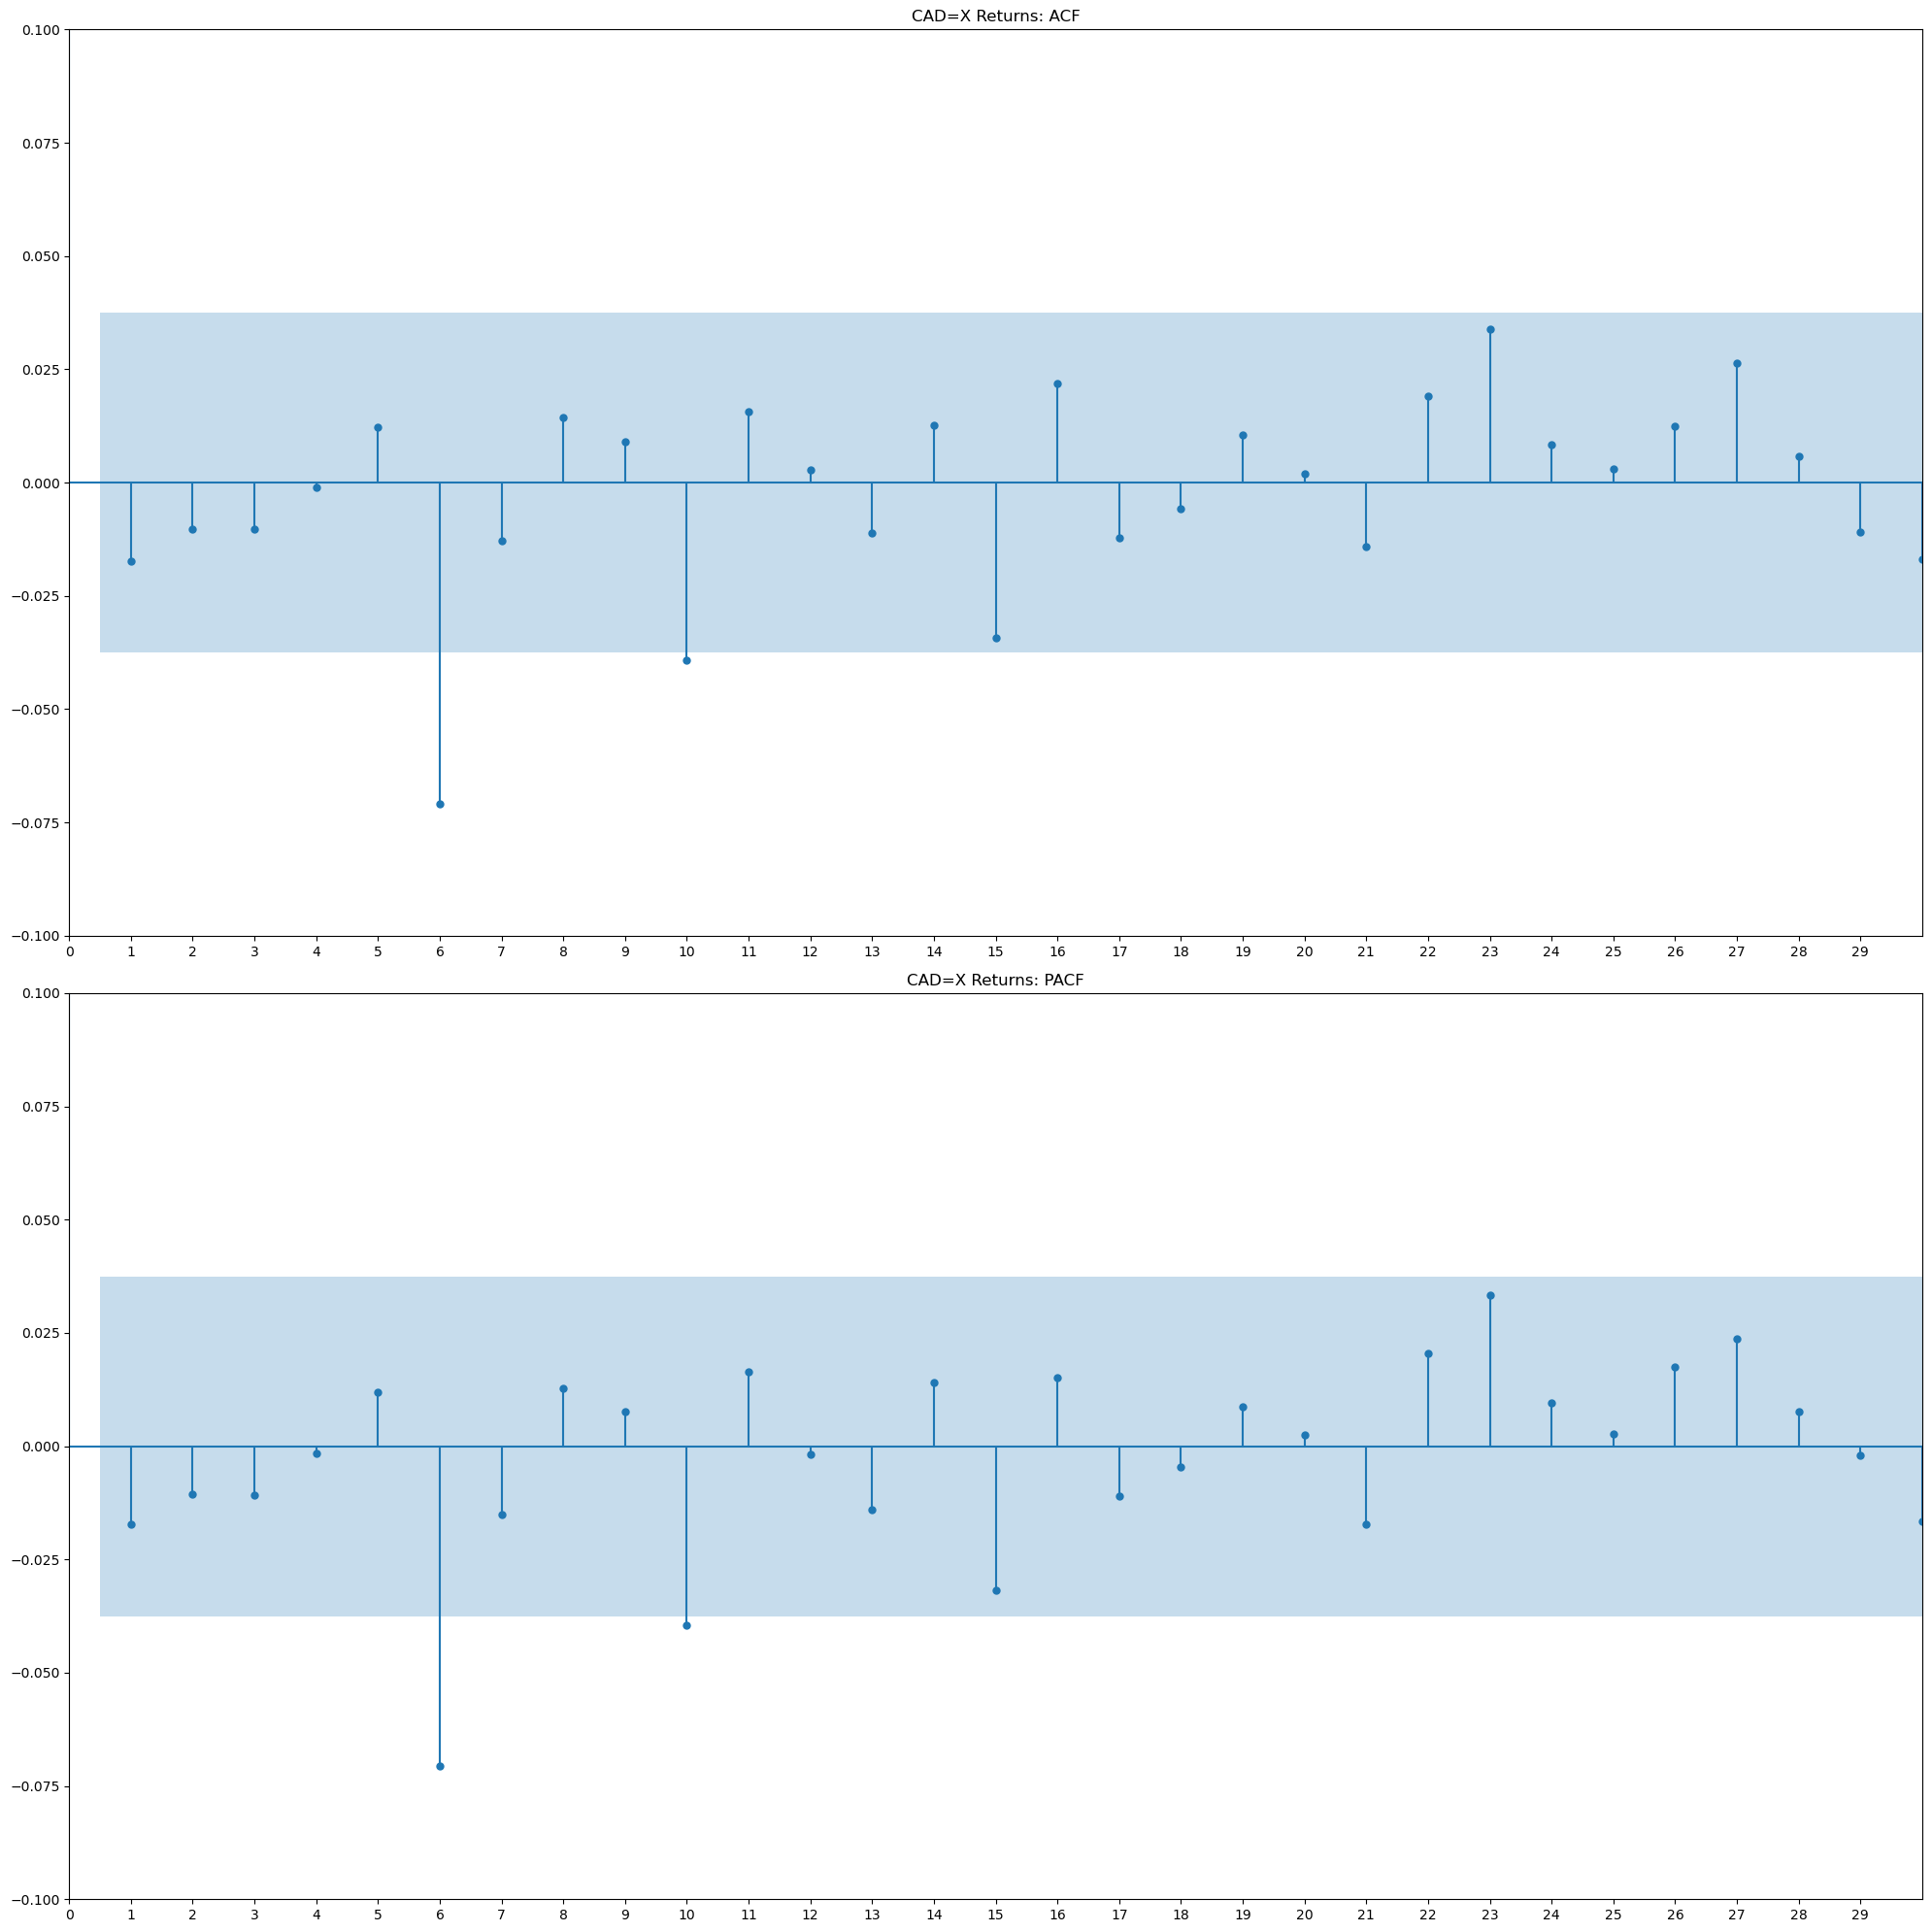

In [97]:
# Plot ACF and PACF of Returns
for ticker in tickers:
    fig, ax = plt.subplots(2, 1, figsize=(20,20))
    ymin, ymax = -0.1, 0.1

    title = f"{ticker} Returns"
    plot_acf(returns[ticker],
            lags=max_lags,
            bartlett_confint=False,
            ax=ax[0])
    ax[0].set_title(f"{title}: ACF")
    ax[0].set_xlim([0, max_lags])
    ax[0].set_ylim([ymin, ymax])
    ax[0].set_xticks(np.arange(0, max_lags, 1))

    plot_pacf(returns[ticker],
                lags=max_lags,
                method='ywmle',
                alpha=0.05,
                use_vlines=True,
                ax=ax[1])
    ax[1].set_title(f"{title}: PACF")
    ax[1].set_xlim([0, max_lags])
    ax[1].set_ylim([ymin, ymax])
    ax[1].set_xticks(np.arange(0, max_lags, 1)) 

    # save plot
    plt.savefig(f"../results/figures/ACF_PACF_returns_{ticker}.png", dpi=300, bbox_inches="tight")
 
    plt.tight_layout() 
    plt.show()

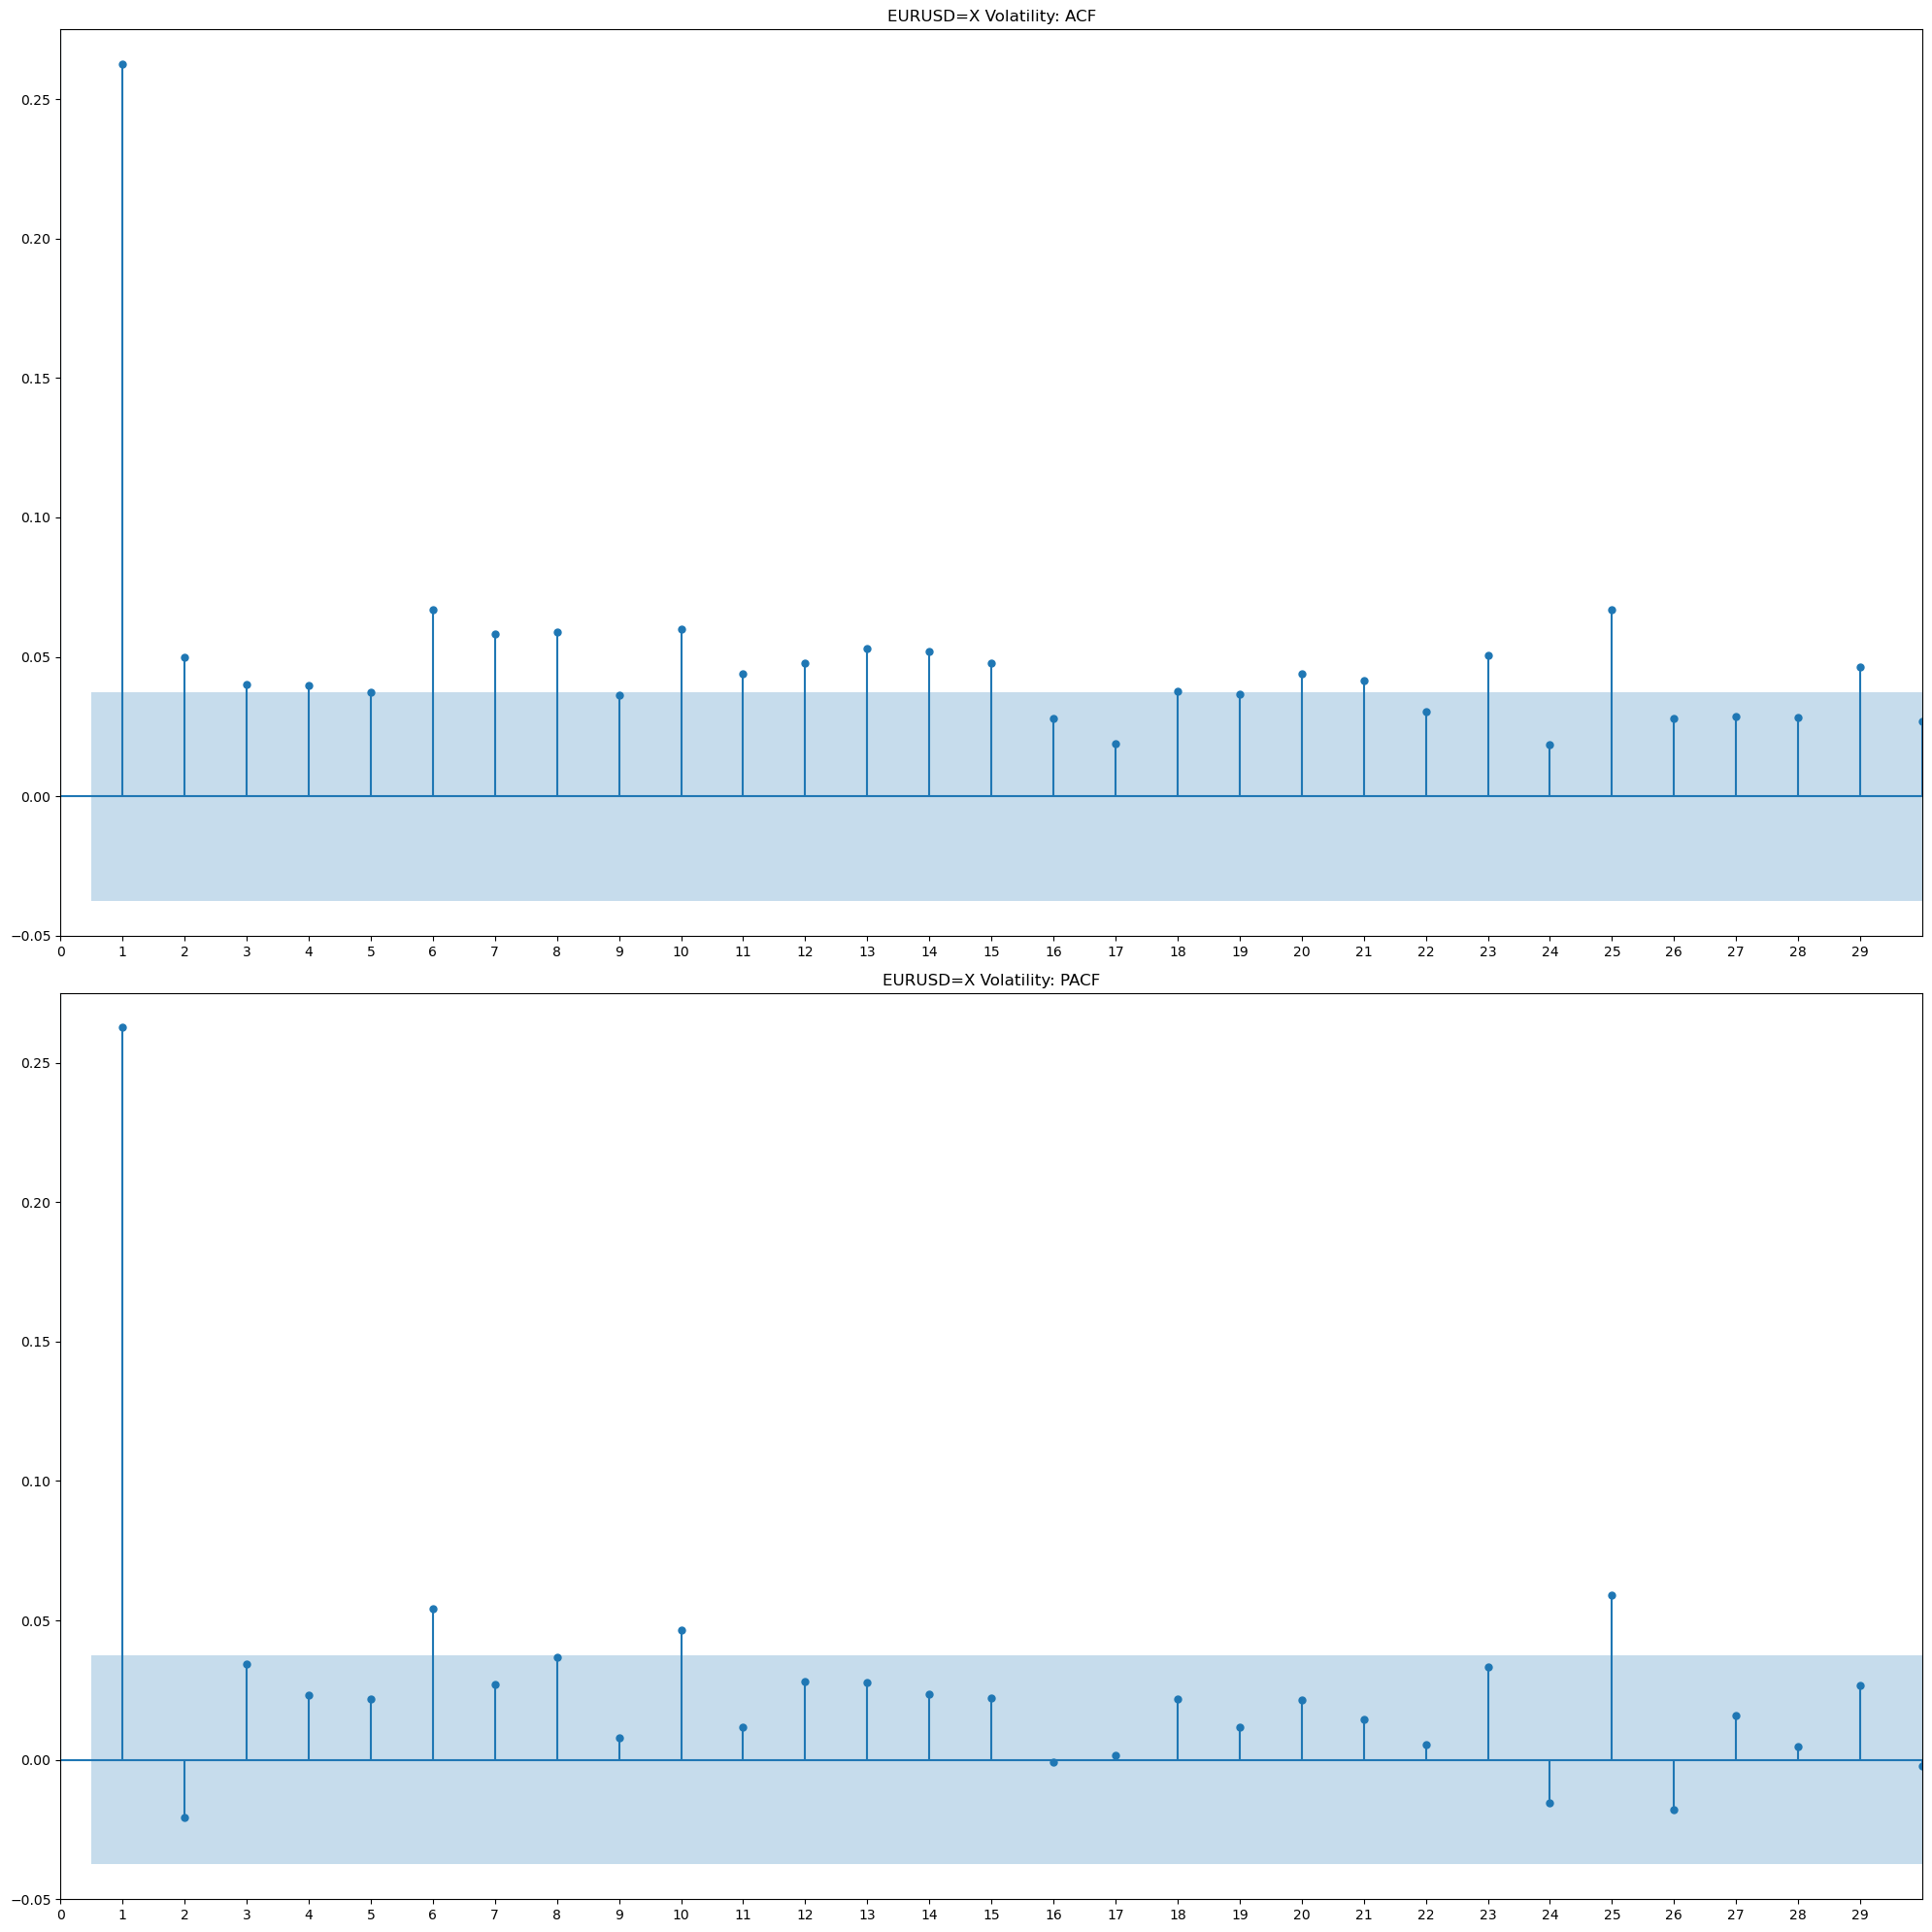

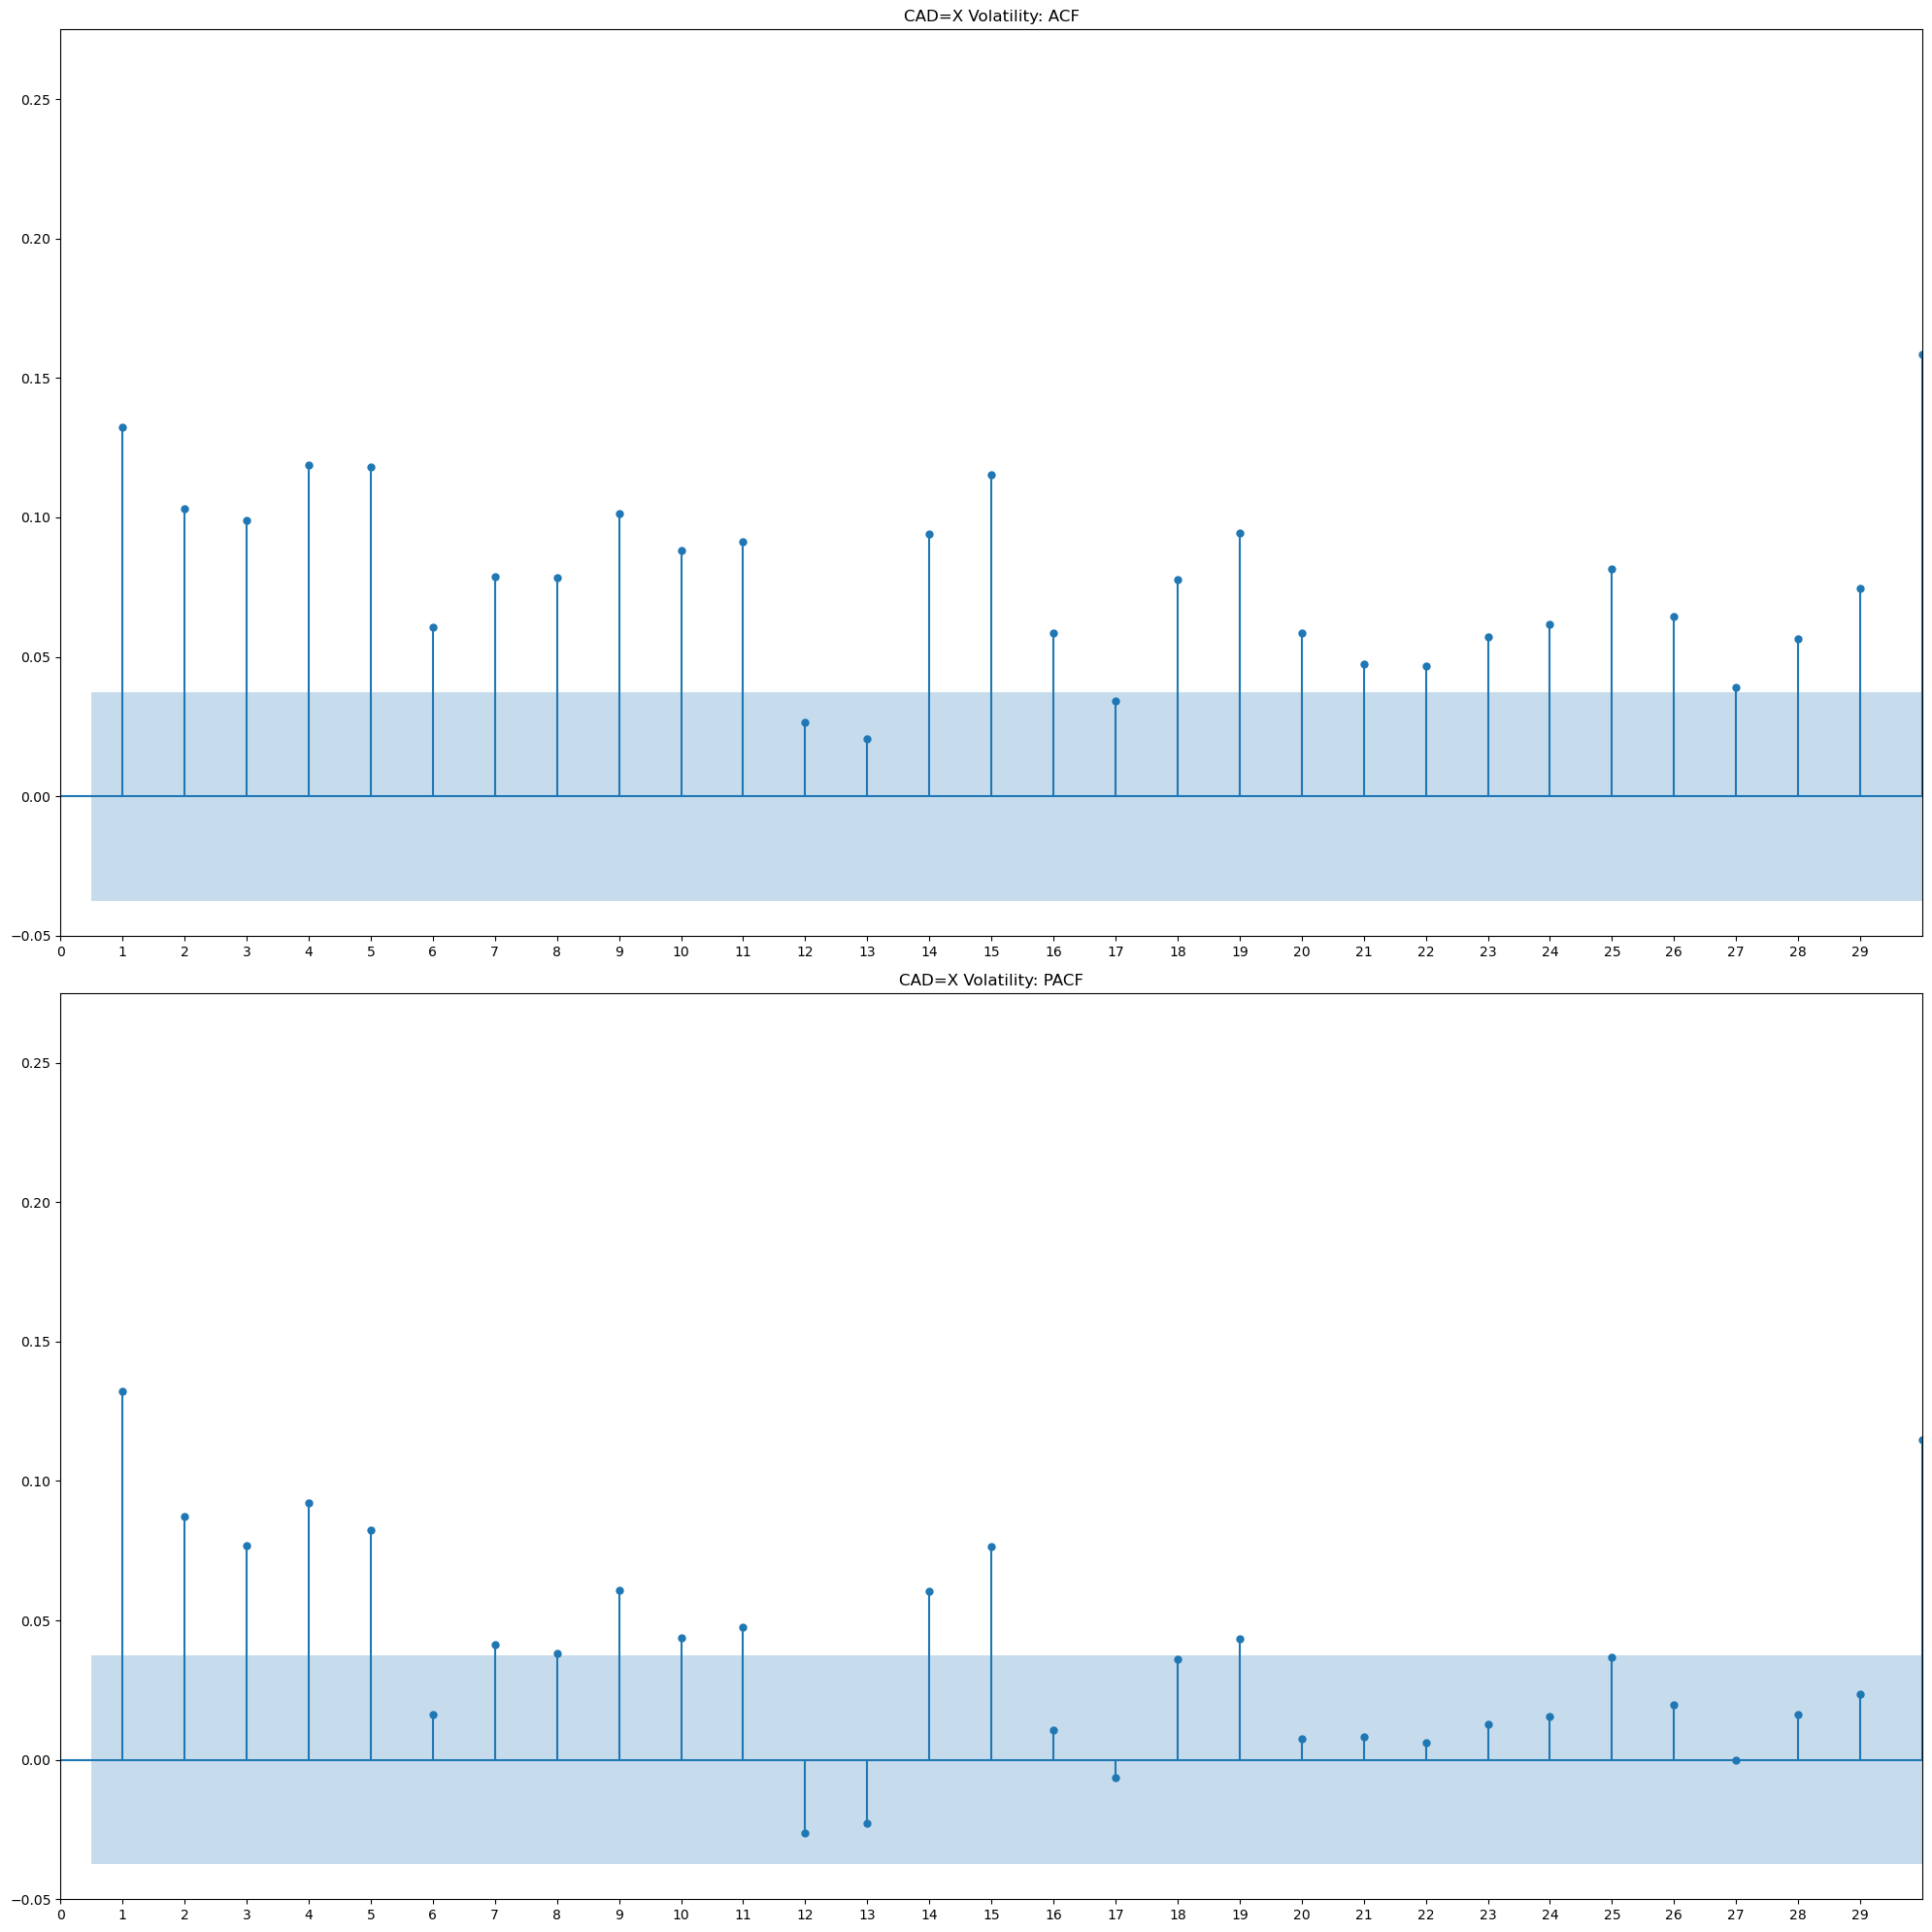

In [108]:
# Plot ACF and PACF of Volatility  
for ticker in tickers:
    fig, ax = plt.subplots(2, 1, figsize=(20,20))
    ymin, ymax = -0.05, 0.275

    title = f"{ticker} Volatility"
    plot_acf(returns_sq[ticker],
            lags=max_lags,
            bartlett_confint=False,
            ax=ax[0])
    ax[0].set_title(f"{title}: ACF")
    ax[0].set_xlim([0, max_lags])
    ax[0].set_ylim([ymin, ymax])
    ax[0].set_xticks(np.arange(0, max_lags, 1))

    plot_pacf(returns_sq[ticker],
                lags=max_lags,
                method='ywmle',
                alpha=0.05,
                use_vlines=True,
                ax=ax[1])
    ax[1].set_title(f"{title}: PACF")
    ax[1].set_xlim([0, max_lags])
    ax[1].set_ylim([ymin, ymax])
    ax[1].set_xticks(np.arange(0, max_lags, 1)) 

    # save plot
    plt.savefig(f"../results/figures/ACF_PACF_volatility_{ticker}.png", dpi=300, bbox_inches="tight")
 
    plt.tight_layout() 
    plt.show()

In [ ]:
# rolling mean


In [ ]:
# rolling volatility


In [ ]:
# plot risk diagnostics: var, es, ?

## Quantitative Analysis

In [101]:
# descriptive statistics
desc_stats = returns.describe()

skewness = returns.skew()
kurtosis = returns.kurtosis() 

# add to descriptive statistics
desc_stats.loc["skew"] = skewness
desc_stats.loc["kurt"] = kurtosis 
 
print('Return Statistics')
desc_stats

Return Statistics


,EURUSD=X,CAD=X
count,2734.000000,2734.000000
mean,0.010372,-0.007915
std,0.459831,0.492985
min,-3.143353,-2.775173
25%,-0.244507,-0.292621
50%,0.013735,-0.009076
75%,0.272410,0.271152
max,3.013790,2.854517
skew,-0.021190,-0.007765
kurt,2.467182,2.603173


In [102]:
# Stationarity Analysis - useful since we are using NBEATs which is interpretable as trend and seasonality
# Note: financial data frequently exhibits both trends and seasonality. 
#   Trends indicate the long-term upward or downward direction (e.g., inflation, growth)
#   Seasonality reps recurring, predictable patterns, like annual stock market performance trends.

# Augmented Dickey-Fuller (adfuller) -> Determines if the series is stationary or needs differencing.
# H0:  The time series has a unit root (non-stationary).
# reject if pvalue < 0.05 

# Kwiatkowski-Phillips-Schmidt-Shin (KPSS) -> Checks for stationarity, confirms ADF test.
# H0: The time series is stationary (around a mean or linear trend).
# reject if pvalue < 0.05

In [ ]:
stationarity_df = pd.DataFrame(index=["adf", "adf_pvalue", "H0 rejection (ADF)", "kpss", "kpss_pvalue", "H0 Rejection (KPSS)"], columns=tickers)
for ticker in tickers:
    # Perform ADF test
    adf_test = adfuller(prices[ticker])
    adf_stat = adf_test[0]
    adf_p = adf_test[1]
    reject_null_adf = 'stationary' if adf_p < 0.05 else 'non-stationary'   

    # Perform KPSS test 
    kps_test = kpss(prices[ticker], regression='ct', nlags='auto')
    kps_stat = kps_test[0]
    kps_p = kps_test[1]
    reject_null_kps = 'non-stationary' if  kps_p < 0.05 else 'stationary'

    stationarity_df[ticker] = [adf_stat, adf_p, reject_null_adf,  kps_stat, kps_p, reject_null_kps]

# save stationarity results to csv
# stationarity_df.to_csv("../results/tables/stationarity_results.csv")

print("Stationarity Results for Prices: ")
stationarity_df

Stationarity Results for Prices: 


,EURUSD=X,CAD=X
adf,-3.076872,-2.649797
adf_pvalue,0.028313,0.083136
H0 rejection (ADF),stationary,non-stationary
kpss,0.728449,0.438816
kpss_pvalue,0.01,0.01
H0 Rejection (KPSS),non-stationary,non-stationary


In [ ]:
stationarity_returns_df = pd.DataFrame(index=["adf", "adf_pvalue", "H0 rejection (ADF)", "kpss", "kpss_pvalue", "H0 Rejection (KPSS)"], columns=tickers)
for ticker in tickers:
    # Perform ADF test
    adf_test = adfuller(returns[ticker])
    adf_stat = adf_test[0]
    adf_p = adf_test[1]
    reject_null_adf = 'stationary' if adf_p < 0.05 else 'non-stationary'   

    # Perform KPSS test 
    kps_test = kpss(returns[ticker], regression='ct', nlags='auto')
    kps_stat = kps_test[0]
    kps_p = kps_test[1]
    reject_null_kps = 'non-stationary' if  kps_p < 0.05 else 'stationary'

    stationarity_returns_df[ticker] = [adf_stat, adf_p, reject_null_adf,  kps_stat, kps_p, reject_null_kps]

# save stationarity results to csv
# stationarity_returns_df.to_csv("../results/tables/stationarity_returns_results.csv")

print("Stationarity Results for Returns: ")
stationarity_returns_df

Stationarity Results for Returns: 


,EURUSD=X,CAD=X
adf,-38.222588,-22.933316
adf_pvalue,0.0,0.0
H0 rejection (ADF),stationary,stationary
kpss,0.071188,0.07766
kpss_pvalue,0.1,0.1
H0 Rejection (KPSS),stationary,stationary


In [ ]:
# Normality Analysis

# Jarque-Bera test for normality
# H0: Returns are normally distributed
# If JB is Large or p-value is small => reject null hypthesis of normality

normality_df = pd.DataFrame(index=["Skewness", "Kurtosis", "JB Statistic", "p-value", "H0 Rejection"], columns=tickers)

for ticker in tickers:
    skewness = returns[ticker].skew()
    kurtosis = returns[ticker].kurtosis()
    jb_stat, p_value = jarque_bera(returns[ticker])
    reject_null = p_value < 0.05

    normality_df[ticker] = [skewness, kurtosis, jb_stat, p_value, reject_null]

# save normality results to csv
# normality_df.to_csv("../results/tables/normality_results.csv")

print("Normality Results: ")
normality_df

Normality Results: 


,EURUSD=X,CAD=X
Skewness,-0.02119,-0.007765
Kurtosis,2.467182,2.603173
JB Statistic,689.85094,767.867174
p-value,0.0,0.0
H0 Rejection,True,True


In [31]:
# Auto Correlation Analysis

# confidence level for autocorrelation significance
conf_level = 0.95 
t_critical = t.ppf((1 + conf_level) / 2, df=len(returns) - 2) 
acf_conf_interval = t_critical / np.sqrt(len(returns)) # confidence interval for autocorrelation
print(f"Autocorrelation significance threshold (95% confidence): ±{acf_conf_interval:.4f}")

# ACF and PACF values for ticker in tickers 
max_lags = 30
for ticker in tickers:
    acf_values = acf(returns[ticker], nlags=max_lags)
    pacf_values = pacf(returns[ticker], nlags=max_lags) 
    corr_df = pd.DataFrame({ 
        "ACF": acf_values,
        "PACF": pacf_values,
        "t-significance": [abs(val) > acf_conf_interval for val in acf_values],
    }) 

    print(f"Autocorrelation values for {ticker}:")
    print(corr_df)

Autocorrelation significance threshold (95% confidence): ±0.0375
Autocorrelation values for EURUSD=X:
         ACF      PACF  t-significance
0   1.000000  1.000000            True
1  -0.009791 -0.009795           False
2  -0.029052 -0.029172           False
3  -0.006606 -0.007199           False
4   0.016590  0.015641           False
5  -0.032821 -0.032995           False
6   0.007646  0.007915           False
7   0.001861  0.000335           False
8   0.015757  0.015578           False
9   0.032744  0.034473           False
10  0.015477  0.015844           False
11 -0.034711 -0.031987           False
12  0.011068  0.011414           False
13 -0.009972 -0.011648           False
14 -0.005367 -0.004023           False
15  0.000531  0.001545           False
16 -0.001810 -0.005439           False
17  0.013542  0.014099           False
18 -0.002901 -0.005051           False
19  0.009979  0.010559           False
20  0.008962  0.011210           False
21 -0.017533 -0.017097           False
2

In [ ]:
# Ljung box test for autocorrelation

# H0: No autocorrelation up to lag k
# If p-value is small => reject null hypothesis of no autocorrelation

for ticker in tickers:
    lb_df = acorr_ljungbox(returns[ticker], lags=max_lags, return_df=True)
    lb_df['H0 Rejection'] = lb_df['lb_pvalue'] < 0.05

    lb_df.index.name = "Lag"

    print(f"Ljung-Box test results for {ticker}:")
    print(lb_df.head(10))

Ljung-Box test results for EURUSD=X:
       lb_stat  lb_pvalue  H0 Rejection
Lag                                    
1     0.262386   0.608486         False
2     2.573360   0.276186         False
3     2.692877   0.441439         False
4     3.446970   0.485987         False
5     6.399635   0.269251         False
6     6.559943   0.363465         False
7     6.569445   0.475040         False
8     7.250705   0.509841         False
9    10.193853   0.335021         False
10   10.851671   0.369190         False
Ljung-Box test results for CAD=X:
       lb_stat  lb_pvalue  H0 Rejection
Lag                                    
1     0.817678   0.365860         False
2     1.105730   0.575299         False
3     1.399487   0.705655         False
4     1.402460   0.843767         False
5     1.812153   0.874478         False
6    15.565292   0.016288          True
7    16.021142   0.024924          True
8    16.583813   0.034747          True
9    16.805484   0.051851         False
10   21.0